In [ ]:
# ============================================================
# WHO NIGERIA HYPERTENSION ANALYSIS
# SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Project Overview

This project analyses trends in hypertension prevalence in Nigeria using World Health Organization (WHO) data. The analysis examines prevalence estimates across sex and over time, with attention to differences between females and males and the uncertainty surrounding reported estimates.

The project demonstrates an end-to-end research analytics workflow, including data exploration, descriptive analysis, trend analysis, uncertainty assessment, statistical testing, visualization, and interpretation of findings.

In [ ]:
# ============================================================
# 1. EXTRACT WHO DATA
# ============================================================

import zipfile
import os

zip_path = "/content/566_Nigeria.zip"
extract_path = "/content/WHO_Nigeria"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("WHO dataset extracted successfully.")
print("Location:", extract_path)

WHO dataset extracted successfully.
Location: /content/WHO_Nigeria


In [ ]:
# ============================================================
# 2. LOAD HYPERTENSION DATASET
# ============================================================

file_path = "/content/WHO_Nigeria/608DE39/566_608DE39_Dataset_2024-01-08.csv"

df = pd.read_csv(file_path)

print("Hypertension dataset loaded successfully.")
print("-" * 50)
print("Shape:", df.shape)
print("Years:", df["DIM_TIME"].min(), "to", df["DIM_TIME"].max())
print("Sex categories:", df["Sex"].unique().tolist())
print("Columns:", df.columns.tolist())

Hypertension dataset loaded successfully.
--------------------------------------------------
Shape: (34, 11)
Years: 1990 to 2018
Sex categories: ['Female', 'Male', 'Total']
Columns: ['IND_UUID', 'IND_NAME', 'DIM_GEO_CODE_TYPE', 'DIM_GEO_CODE_M49', 'GEO_NAME_SHORT', 'DIM_TIME_TYPE', 'DIM_TIME', 'Sex', 'RATE_PER_100_N', 'RATE_PER_100_NL', 'RATE_PER_100_NU']


In [ ]:
# ============================================================
# 3. CREATE UNCERTAINTY WIDTH
# ============================================================

df["uncertainty_width"] = (
    df["RATE_PER_100_NU"] - df["RATE_PER_100_NL"]
)

print("Uncertainty variable created successfully.")
print("New dataset shape:", df.shape)
print("New column:", "uncertainty_width")

Uncertainty variable created successfully.
New dataset shape: (34, 12)
New column: uncertainty_width


## 4. Data Quality and Structure

Before analysis, the dataset was examined to confirm its dimensions, observation years, sex categories, and available observations.

The extracted Nigeria dataset contains 34 observations across Female, Male, and Total categories, covering observed estimates from 1990 to 2018. The observations are not evenly distributed across sex-specific series. Missing years were retained as missing observations and were not treated as zero or interpolated.

The dataset contains the estimated prevalence (`RATE_PER_100_N`) together with lower (`RATE_PER_100_NL`) and upper (`RATE_PER_100_NU`) uncertainty limits.

In [ ]:
# ============================================================
# DATA QUALITY CHECKS
# ============================================================

print("Dataset shape:", df.shape)
print("\nSex categories:")
print(df["Sex"].value_counts())

print("\nObserved years by sex:")
print(
    df.groupby("Sex")["DIM_TIME"]
      .agg(["min", "max", "count"])
)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (34, 12)

Sex categories:
Sex
Female    20
Male       7
Total      7
Name: count, dtype: int64

Observed years by sex:
         min   max  count
Sex                      
Female  1990  2017     20
Male    1990  2015      7
Total   1990  2018      7

Missing values:
IND_UUID             0
IND_NAME             0
DIM_GEO_CODE_TYPE    0
DIM_GEO_CODE_M49     0
GEO_NAME_SHORT       0
DIM_TIME_TYPE        0
DIM_TIME             0
Sex                  0
RATE_PER_100_N       0
RATE_PER_100_NL      0
RATE_PER_100_NU      0
uncertainty_width    0
dtype: int64

Duplicate rows: 0


## 5. Descriptive Analysis

Descriptive statistics were used to summarize the observed age-standardized hypertension prevalence by sex. For each category, the analysis reports the number of observations, first and last observed years, first and last observed prevalence estimates, mean prevalence, and mean reported uncertainty width.

In [ ]:
# ============================================================
# TABLE 1 — DESCRIPTIVE SUMMARY
# ============================================================

summary = (
    df.sort_values("DIM_TIME")
      .groupby("Sex")
      .agg(
          n_observations=("DIM_TIME", "count"),
          first_year=("DIM_TIME", "min"),
          last_year=("DIM_TIME", "max"),
          first_observed_prevalence=("RATE_PER_100_N", "first"),
          last_observed_prevalence=("RATE_PER_100_N", "last"),
          mean_prevalence=("RATE_PER_100_N", "mean"),
          mean_uncertainty_width=("uncertainty_width", "mean")
      )
      .reset_index()
)

summary

,Sex,n_observations,first_year,last_year,first_observed_prevalence,last_observed_prevalence,mean_prevalence,mean_uncertainty_width
0,Female,20,1990,2017,35.9,38.8,37.190000,17.630000
1,Male,7,1990,2015,34.1,33.6,34.114286,17.785714
2,Total,7,1990,2018,35.1,36.1,35.742857,13.014286


## 6. First-to-Last Observed Changes

Changes in hypertension prevalence were calculated between the first and last observed estimates available for each sex category.

Because the dataset contains uneven observation years across sex categories, these comparisons refer to the first and last observed estimates rather than equivalent fixed time points across all groups.

In [ ]:
# ============================================================
# FIRST-TO-LAST OBSERVED CHANGES
# ============================================================

change_summary = summary.copy()

change_summary["absolute_change_pp"] = (
    change_summary["last_observed_prevalence"]
    - change_summary["first_observed_prevalence"]
)

change_summary["percentage_change"] = (
    change_summary["absolute_change_pp"]
    / change_summary["first_observed_prevalence"]
) * 100

change_summary[
    [
        "Sex",
        "first_year",
        "last_year",
        "first_observed_prevalence",
        "last_observed_prevalence",
        "absolute_change_pp",
        "percentage_change"
    ]
]

,Sex,first_year,last_year,first_observed_prevalence,last_observed_prevalence,absolute_change_pp,percentage_change
0,Female,1990,2017,35.9,38.8,2.9,8.077994
1,Male,1990,2015,34.1,33.6,-0.5,-1.466276
2,Total,1990,2018,35.1,36.1,1.0,2.849003


## 7. Female–Male Comparison

Female and male estimates were compared only in years for which both sex-specific estimates were available. For each overlapping year, the female–male difference was calculated in percentage points.

This approach avoids treating missing sex-specific observations as zero or creating estimates for years that were not reported in the dataset.

In [ ]:
# ============================================================
# TABLE 2 — FEMALE-MALE COMPARISON
# ============================================================

female_male = df[df["Sex"].isin(["Female", "Male"])].copy()

# Identify years where both Female and Male are observed
overlap_years = (
    female_male
    .groupby("DIM_TIME")["Sex"]
    .nunique()
)

overlap_years = overlap_years[overlap_years == 2].index

# Create comparison table
comparison = (
    female_male[
        female_male["DIM_TIME"].isin(overlap_years)
    ]
    .pivot(
        index="DIM_TIME",
        columns="Sex",
        values="RATE_PER_100_N"
    )
    .reset_index()
)

comparison["female_minus_male"] = (
    comparison["Female"] - comparison["Male"]
)

comparison = comparison.sort_values("DIM_TIME")

print("Overlapping years:")
print(comparison["DIM_TIME"].tolist())

print("\nFemale–Male comparison:")
comparison

Overlapping years:
[1990, 1994, 1997, 2008, 2010, 2014, 2015]

Female–Male comparison:


Sex,DIM_TIME,Female,Male,female_minus_male
0,1990,35.9,34.1,1.8
1,1994,36.0,34.0,2.0
2,1997,36.1,34.1,2.0
3,2008,38.0,34.7,3.3
4,2010,38.2,34.5,3.7
5,2014,38.4,33.8,4.6
6,2015,38.5,33.6,4.9


In [ ]:
# ============================================================
# AVERAGE OBSERVED FEMALE–MALE GAP
# ============================================================

average_gap = comparison["female_minus_male"].mean()

print(
    f"Average observed female–male difference: "
    f"{average_gap:.2f} percentage points"
)

Average observed female–male difference: 3.19 percentage points


## 8. Uncertainty Analysis

Reported uncertainty was examined using the width of the uncertainty interval, calculated as the upper estimate minus the lower estimate.

Larger values indicate wider reported uncertainty intervals, while smaller values indicate narrower intervals. The analysis describes these reported widths and their variation over time; it does not interpret narrower intervals as proof of greater accuracy.

In [ ]:
# ============================================================
# UNCERTAINTY SUMMARY BY SEX
# ============================================================

uncertainty_summary = (
    df.groupby("Sex")["uncertainty_width"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          minimum="min",
          maximum="max"
      )
      .reset_index()
)

uncertainty_summary

,Sex,count,mean,median,minimum,maximum
0,Female,20,17.630000,15.15,10.9,31.7
1,Male,7,17.785714,13.00,11.5,31.5
2,Total,7,13.014286,9.60,8.3,22.3


In [ ]:
# ============================================================
# FEMALE UNCERTAINTY BY PERIOD
# ============================================================

female = (
    df[df["Sex"] == "Female"]
    .sort_values("DIM_TIME")
    .copy()
)

female_early = female[female["DIM_TIME"] <= 1999]
female_later = female[female["DIM_TIME"] >= 2000]

print("Female uncertainty width")
print("-" * 40)

print(
    "1990–1999 mean:",
    round(female_early["uncertainty_width"].mean(), 2)
)

print(
    "2000 onward mean:",
    round(female_later["uncertainty_width"].mean(), 2)
)

difference = (
    female_early["uncertainty_width"].mean()
    - female_later["uncertainty_width"].mean()
)

percentage_narrower = (
    difference
    / female_early["uncertainty_width"].mean()
) * 100

print(
    "Absolute difference:",
    round(difference, 2)
)

print(
    "Percentage narrower:",
    round(percentage_narrower, 2),
    "%"
)

Female uncertainty width
----------------------------------------
1990–1999 mean: 24.23
2000 onward mean: 12.23
Absolute difference: 12.01
Percentage narrower: 49.54 %


## 9. Statistical Analysis

Spearman rank correlation was used to examine the association between observation year and age-standardized hypertension prevalence within each sex category.

Spearman correlation was selected because the available observations were unevenly distributed across years and the analysis was intended to describe monotonic temporal patterns rather than assume a linear relationship.

Results are interpreted as descriptive associations and not as evidence of causation.

In [ ]:
# ============================================================
# TABLE 3 — SPEARMAN CORRELATION RESULTS
# ============================================================

rows = []

for sex in ["Female", "Male", "Total"]:

    subset = df[df["Sex"] == sex]

    rho, p = spearmanr(
        subset["DIM_TIME"],
        subset["RATE_PER_100_N"]
    )

    rows.append({
        "Group": sex,
        "n": len(subset),
        "Spearman_rho": rho,
        "p_value": p
    })

spearman_results = pd.DataFrame(rows)

spearman_results

,Group,n,Spearman_rho,p_value
0,Female,20,0.996611,5.535023e-21
1,Male,7,-0.396412,3.786347e-01
2,Total,7,0.654921,1.103707e-01


## 10. Visualizations

Three figures were generated to summarize the main findings:

1. Overall age-standardized hypertension prevalence by sex.
2. The observed female–male difference in overlapping years.
3. Female hypertension prevalence estimates with reported uncertainty intervals.

Figures are saved as high-resolution PNG files for use in the manuscript and portfolio repository.

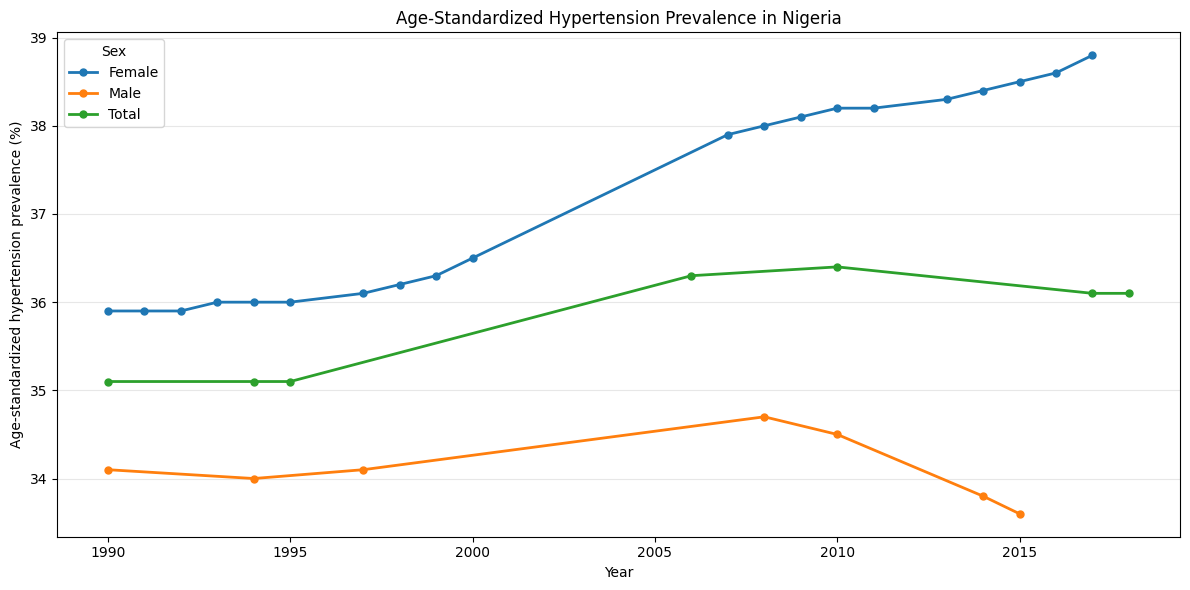

In [ ]:
# ============================================================
# FIGURE 1 — PREVALENCE TRENDS
# ============================================================

fig_dir = "/content/nigeria_hypertension_github/figures"
os.makedirs(fig_dir, exist_ok=True)

plt.figure(figsize=(12, 6))

for sex in ["Female", "Male", "Total"]:

    subset = (
        df[df["Sex"] == sex]
        .sort_values("DIM_TIME")
    )

    plt.plot(
        subset["DIM_TIME"],
        subset["RATE_PER_100_N"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=sex
    )

plt.xlabel("Year")
plt.ylabel("Age-standardized hypertension prevalence (%)")
plt.title("Age-Standardized Hypertension Prevalence in Nigeria")
plt.legend(title="Sex")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        fig_dir,
        "figure_1_prevalence_trends.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

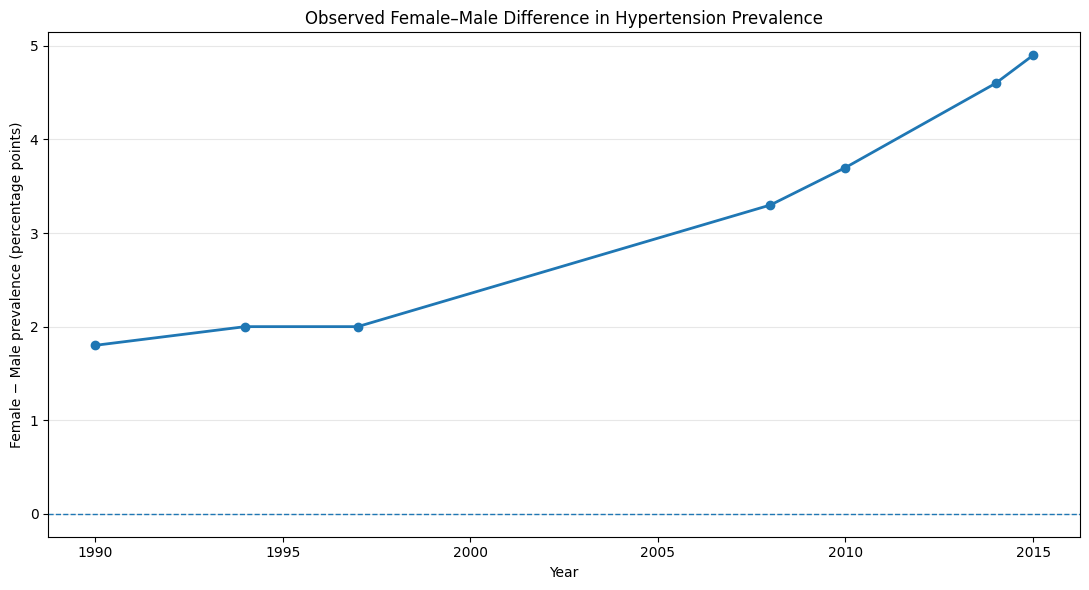

In [ ]:
# ============================================================
# FIGURE 2 — FEMALE-MALE DIFFERENCE
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    comparison["DIM_TIME"],
    comparison["female_minus_male"],
    marker="o",
    linewidth=2,
    markersize=6
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Female − Male prevalence (percentage points)")
plt.title(
    "Observed Female–Male Difference in Hypertension Prevalence"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        fig_dir,
        "figure_2_female_male_difference.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

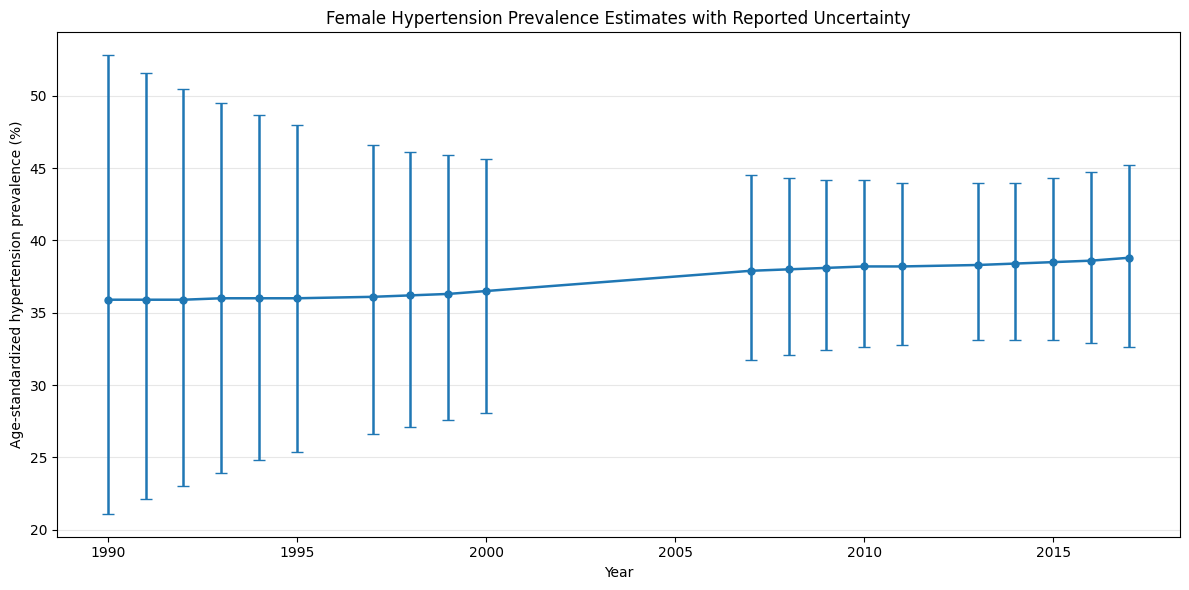

In [ ]:
# ============================================================
# FIGURE 3 — FEMALE PREVALENCE WITH UNCERTAINTY
# ============================================================

plt.figure(figsize=(12, 6))

plt.errorbar(
    female["DIM_TIME"],
    female["RATE_PER_100_N"],
    yerr=[
        female["RATE_PER_100_N"]
        - female["RATE_PER_100_NL"],

        female["RATE_PER_100_NU"]
        - female["RATE_PER_100_N"]
    ],
    fmt="o-",
    linewidth=1.8,
    markersize=5,
    capsize=4
)

plt.xlabel("Year")
plt.ylabel("Age-standardized hypertension prevalence (%)")
plt.title(
    "Female Hypertension Prevalence Estimates with Reported Uncertainty"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        fig_dir,
        "figure_3_female_uncertainty.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 11. EXPORT FINAL TABLES
# ============================================================

import os

output_dir = "/content/nigeria_hypertension_github"
table_dir = os.path.join(output_dir, "tables")

os.makedirs(table_dir, exist_ok=True)

# Table 1: Descriptive summary
summary.to_csv(
    os.path.join(table_dir, "table_1_descriptive_summary.csv"),
    index=False
)

# Table 2: Female–male comparison
comparison.to_csv(
    os.path.join(table_dir, "table_2_female_male_comparison.csv"),
    index=False
)

# Table 3: Spearman results
spearman_results.to_csv(
    os.path.join(table_dir, "table_3_spearman_results.csv"),
    index=False
)

print("Final tables exported successfully.")
print("Location:", table_dir)
print()
print("Files:")
for file in sorted(os.listdir(table_dir)):
    print("-", file)

## 12. Key Findings

The analysis identified several main patterns in the WHO estimates for Nigeria.

- Among female-specific estimates, age-standardized hypertension prevalence increased from 35.9% in 1990 to 38.8% in 2017, representing an absolute increase of 2.9 percentage points.
- Among male-specific estimates, prevalence changed from 34.1% in 1990 to 33.6% in 2015, a decrease of 0.5 percentage points.
- The total-population estimate increased from 35.1% in 1990 to 36.1% in 2018.
- In all seven years where female and male estimates overlapped, the female estimate was higher than the male estimate.
- The observed female–male difference increased from 1.8 percentage points in 1990 to 4.9 percentage points in 2015. The average observed difference across overlapping years was 3.19 percentage points.
- Reported uncertainty intervals were wider in the earlier observations and became substantially narrower in the later female-specific estimates. The mean uncertainty width decreased from 24.23 percentage points during 1990–1999 to 12.23 percentage points from 2000 onward.
- Spearman analysis showed a very strong positive association between year and female hypertension prevalence (ρ = 0.997, p < 0.001). The male and total series showed weaker associations that were not statistically significant.

These findings describe patterns in the WHO estimates and should not be interpreted as evidence of causal relationships. The estimates are model-based, and the available observations are uneven across years and sex groups.

## 13. Limitations
This analysis has several limitations. First, the analysis is based on a secondary WHO dataset, so the study is limited to the variables, years, definitions, and level of disaggregation available in the source data. Second, the available observations are not evenly distributed across sex categories and years, which limits direct comparison of trends across groups and periods. Third, the analysis is descriptive and observational; therefore, changes in the reported rates cannot be interpreted as causal effects of any specific factor or intervention. Fourth, the reported estimates include uncertainty bounds, meaning that observed differences should be interpreted with appropriate caution rather than as exact values. Finally, this analysis focuses on the available national-level indicator data and does not account for potential differences between Nigerian states, regions, or other population subgroups.

## 14. Conclusion

This analysis examined the available WHO indicator data for Nigeria, focusing on differences by sex, changes over time, and the uncertainty surrounding the reported estimates. The findings demonstrate the value of disaggregating health indicators rather than relying only on overall estimates, as patterns can differ between population groups and across time.

The analysis also highlights the importance of interpreting health estimates alongside their uncertainty and considering the limitations of the underlying data. Overall, the project demonstrates how publicly available health data can be transformed into a structured, reproducible analysis that supports evidence-based understanding of population health trends in Nigeria.

## 15. Interpretation

The findings suggest that the trajectory of age-standardized hypertension prevalence differed by sex in the available WHO estimates for Nigeria. Female-specific estimates showed a clear upward pattern across the observed period, whereas male estimates remained comparatively stable and ended slightly below their 1990 value. The female estimate was higher than the male estimate in every overlapping observation, with the observed difference reaching 4.9 percentage points by 2015.

The uncertainty intervals also changed considerably over time. The narrowing of the reported intervals indicates that the later estimates were accompanied by smaller uncertainty ranges than the earlier estimates. However, the dataset alone does not establish why this occurred, and narrower intervals should not automatically be interpreted as evidence that the estimates are more accurate.

The findings should also be interpreted in the context of the WHO methodology. These are age-standardized, model-based estimates rather than direct measurements from a single Nigerian population survey. Differences between these estimates and estimates reported in individual Nigerian studies or meta-analyses may therefore reflect differences in population age ranges, study periods, sampling methods, standardization, and statistical modelling.

Overall, the analysis provides a standardized view of how hypertension prevalence estimates for Nigerian adults aged 30–79 years varied over time and between sexes. It also demonstrates the importance of considering uncertainty when interpreting long-term health indicators.

## 16. References

1. World Health Organization. *Age-standardized prevalence of hypertension among adults aged 30 to 79 years (%).* WHO Data. Indicator 608DE39. Updated January 8, 2024.

2. NCD Risk Factor Collaboration (NCD-RisC). Worldwide trends in hypertension prevalence and progress in treatment and control from 1990 to 2019: a pooled analysis of 1201 population-representative studies with 104 million participants. *The Lancet.* 2021;398(10304):957–980. doi:10.1016/S0140-6736(21)01330-1.

3. Adeloye D, Basquill C, Aderemi AV, Thompson JY, Obi FA. An estimate of the prevalence of hypertension in Nigeria: a systematic review and meta-analysis. *Journal of Hypertension.* 2015;33(2):230–242. doi:10.1097/HJH.0000000000000413.

4. Adeloye D, Owolabi EO, Ojji DB, Auta A, Dewan MT, Olanrewaju TO, et al. Prevalence, awareness, treatment, and control of hypertension in Nigeria in 1995 and 2020: a systematic analysis of current evidence. *The Journal of Clinical Hypertension.* 2021;23(5):963–977. doi:10.1111/jch.14220.

5. Nwankwo M, Makena W, Idris A, Barnabas D, Danborno AM, Umoren EB. Prevalence of hypertension among adults in Nigeria: a systematic review and meta-analysis. *BMC Cardiovascular Disorders.* 2026;26(1):330. doi:10.1186/s12872-026-05722-y.